## 1. Setup — Import Libraries & Load Data

In [19]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.metrics import roc_curve

In [2]:
try:
    X_train = joblib.load("X_train.pkl")
    X_test = joblib.load("X_test.pkl")
    y_train = joblib.load("y_train.pkl")
    y_test = joblib.load("y_test.pkl")
except FileNotFoundError as e:
    print(f"Error: pickle file not found — {e}")
else:
    print("Loaded successfully")
    print("X_train:", X_train.shape, "y_train:", y_train.shape)
    print("X_test :", X_test.shape, "y_test :", y_test.shape)

Loaded successfully
X_train: (3996, 42) y_train: (3996,)
X_test : (1000, 42) y_test : (1000,)


## 2. Baseline Model
Default hyperparameters are used to establish a baseline performance before optimization.

In [14]:
svm = SVC(random_state=42, probability=True)
svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)
svm_accuracy = accuracy_score(y_test, svm_pred)

print("Baseline Accuracy:", svm_accuracy)
print(classification_report(y_test, svm_pred))

Baseline Accuracy: 0.788
              precision    recall  f1-score   support

           0       0.78      0.72      0.75       438
           1       0.79      0.84      0.82       562

    accuracy                           0.79      1000
   macro avg       0.79      0.78      0.78      1000
weighted avg       0.79      0.79      0.79      1000



## 3. Hyperparameter Tuning
Grid Search evaluates different values of `C`, `kernel`, and `gamma` to determine the optimal combination of hyperparameters for the SVM model.

In [17]:
param_grid = {
    "C": [0.1, 1, 10, 100],
    "kernel": ["linear", "rbf", "poly"],
    "gamma": ["scale", "auto"],
}

grid_search = GridSearchCV(
    SVC(random_state=42, probability=True),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
best_svm = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)

best_parameters = pd.DataFrame({
    "Parameter": grid_search.best_params_.keys(),
    "Best Value": grid_search.best_params_.values()
})

best_parameters

Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV Accuracy: 0.8140588235294117


,Parameter,Best Value
0,C,10
1,gamma,scale
2,kernel,rbf


## 4. Best Model Evaluation 
The optimized SVM model obtained from Grid Search is evaluated using the testing dataset, including a confusion matrix to visualize classification performance.

In [5]:
best_pred = best_svm.predict(X_test)
best_accuracy = accuracy_score(y_test, best_pred)

print("Testing Accuracy:", best_accuracy)
print(classification_report(y_test, best_pred))

Testing Accuracy: 0.822
              precision    recall  f1-score   support

           0       0.81      0.78      0.79       438
           1       0.83      0.86      0.84       562

    accuracy                           0.82      1000
   macro avg       0.82      0.82      0.82      1000
weighted avg       0.82      0.82      0.82      1000



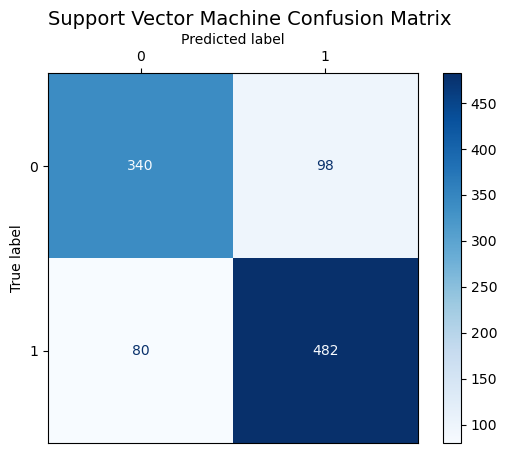

In [6]:
ConfusionMatrixDisplay.from_estimator(
    best_svm,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Support Vector Machine Confusion Matrix", fontsize=14, loc='left')
plt.gca().xaxis.tick_top()
plt.gca().xaxis.set_label_position("top")
plt.xlabel("Predicted label", fontsize=10)
plt.ylabel("True label", fontsize=10)

plt.show()

## 5. Model Stability — 10-Fold Cross-Validation 
The training data is divided into 10 equal subsets; nine are used for training and one for testing in each iteration, to evaluate the stability and generalization performance of the optimized model.

[0.8325     0.815      0.7925     0.8225     0.82       0.81
 0.81704261 0.81203008 0.80952381 0.78195489]
Average Accuracy: 0.8113051378446114
Standard Deviation: 0.013846265822234981


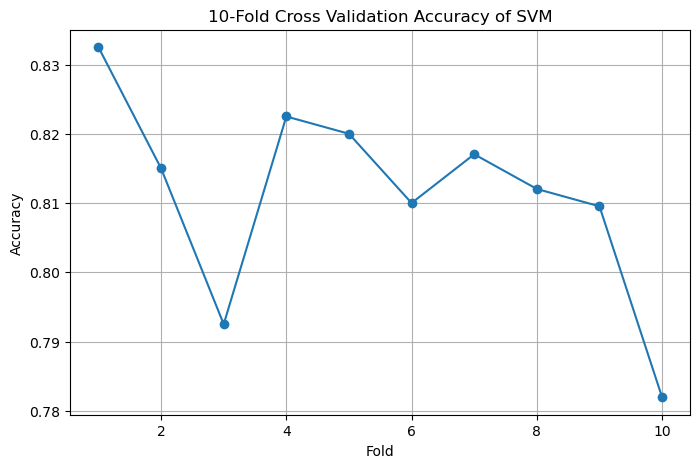

,Fold,Accuracy
0,1,0.832500
1,2,0.815000
2,3,0.792500
3,4,0.822500
4,5,0.820000
5,6,0.810000
6,7,0.817043
7,8,0.812030
8,9,0.809524
9,10,0.781955


In [7]:
scores = cross_val_score(best_svm, X_train, y_train, cv=10, scoring="accuracy")

print(scores)
print("Average Accuracy:", scores.mean())
print("Standard Deviation:", scores.std())

cv_results = pd.DataFrame({
    "Fold": range(1, 11),
    "Accuracy": scores
})

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), scores, marker='o')
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("10-Fold Cross Validation Accuracy of SVM")
plt.grid(True)
plt.show()

cv_results

## 6. YOuden's J Statistic 
Decision Threshold Optimisation

In [18]:
from sklearn.metrics import roc_curve
import numpy as np

# get predicted probabilities (not just 0/1 labels)
y_probs = best_svm.predict_proba(X_test)[:, 1]

# calculate the ROC curve: false positive rate, true positive rate, thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

# Youden's J statistic = sensitivity + specificity - 1 = tpr - fpr
j_scores = tpr - fpr
best_threshold_idx = np.argmax(j_scores)
best_threshold = thresholds[best_threshold_idx]

print(f"Optimal threshold: {best_threshold:.4f}")
print(f"Youden's J at this threshold: {j_scores[best_threshold_idx]:.4f}")

# apply the new threshold instead of the default 0.5
y_pred_optimal = (y_probs >= best_threshold).astype(int)

from sklearn.metrics import accuracy_score, classification_report
print("\\nAccuracy with optimal threshold:", accuracy_score(y_test, y_pred_optimal))
print(classification_report(y_test, y_pred_optimal))

Optimal threshold: 0.6718
Youden's J at this threshold: 0.6706
\nAccuracy with optimal threshold: 0.833
              precision    recall  f1-score   support

           0       0.78      0.85      0.82       438
           1       0.88      0.82      0.85       562

    accuracy                           0.83      1000
   macro avg       0.83      0.84      0.83      1000
weighted avg       0.84      0.83      0.83      1000



## 7. Additional Diagnostics
Training-vs-testing accuracy checks for overfitting/underfitting, a kernel comparison shows how different kernels perform against each other, and the support vector count shows how many training points define the decision boundary for each class.

In [8]:
# training vs testing accuracy
train_pred = best_svm.predict(X_train)
test_pred = best_svm.predict(X_test)

train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

comparison = pd.DataFrame({
    "Dataset": ["Training", "Testing"],
    "Accuracy": [train_acc, test_acc]
})
print(comparison, "\n")

# kernel comparison
kernels = ["linear", "rbf", "poly"]
kernel_result = []

for kernel in kernels:
    model = SVC(kernel=kernel, random_state=42)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    kernel_result.append({"Kernel": kernel, "Accuracy": accuracy_score(y_test, pred)})

kernel_result = pd.DataFrame(kernel_result)
print(kernel_result, "\n")

# number of support vectors per class
print("Support Vectors for Each Class:", best_svm.n_support_)

    Dataset  Accuracy
0  Training  0.912913
1   Testing  0.822000 

   Kernel  Accuracy
0  linear     0.763
1     rbf     0.788
2    poly     0.795 

Support Vectors for Each Class: [ 958 1048]


## 8. Result Summary & Save Model

In [9]:
summary = pd.DataFrame({
    "Metric": [
        "Best Kernel",
        "Best C",
        "Best Gamma",
        "Testing Accuracy",
        "Cross Validation Accuracy",
        "Cross Validation Std",
        "Training Accuracy"
    ],
    "Value": [
        grid_search.best_params_["kernel"],
        grid_search.best_params_["C"],
        grid_search.best_params_["gamma"],
        best_accuracy,
        scores.mean(),
        scores.std(),
        train_acc
    ]
})

summary

,Metric,Value
0,Best Kernel,rbf
1,Best C,10
2,Best Gamma,scale
3,Testing Accuracy,0.822
4,Cross Validation Accuracy,0.811305
5,Cross Validation Std,0.013846
6,Training Accuracy,0.912913


In [10]:
# save the trained model
joblib.dump(best_svm, 'svm_model.pkl')
print("Model saved successfully!")

Model saved successfully!
